# Machine Learning Classification of Diffusion Regimes

Given an experimental trajectory from particle tracking or X-ray photon
correlation spectroscopy (XPCS), can we automatically assign a diffusion
regime without knowing the underlying polymer concentration or NP charge?
This is the inverse problem that matters experimentally: the observer sees
only the particle trajectory, not the system parameters. Supervised
classification trained on simulation data with known labels offers one
route to answering this question.

An important caveat is that the regime labels here derive from simulation
parameters through the rule-based classifier in `src/features.py`. The
machine learning models therefore learn to reproduce those rules from the
feature vector, not from ground-truth experimental observations. The primary
value is in identifying which trajectory features are most diagnostic of each
regime, which guides what to measure in experiments.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.ml_models import (prepare_data, train_random_forest,
                            train_gradient_boosting, evaluate_model,
                            get_cv_scores)
from sklearn.model_selection import learning_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load feature matrix saved by notebook 05
feat_df = pd.read_csv('../feature_matrix.csv')
print(f'Feature matrix: {feat_df.shape[0]} trajectories, {feat_df.shape[1]} columns.')
print('\nClass distribution:')
print(feat_df['diffusion_regime'].value_counts().to_string())

X_train, X_test, y_train, y_test, scaler, feature_names, le = prepare_data(feat_df)
print(f'\nTrain size: {len(X_train)}, Test size: {len(X_test)}')


Feature matrix: 160 trajectories, 22 columns.

Class distribution:
diffusion_regime
free       111
mixed       44
subdiff      5

Train size: 128, Test size: 32


In [4]:
# Train Random Forest
rf_model, rf_cv = train_random_forest(X_train, y_train)


/home/ahmad/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Random Forest -- best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 300}
Random Forest -- best CV F1 macro: 0.6558


In [5]:
# Train Gradient Boosting
gb_model, gb_cv = train_gradient_boosting(X_train, y_train)


/home/ahmad/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Gradient Boosting -- best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Gradient Boosting -- best CV F1 macro: 1.0000



=== Random Forest ===
              precision    recall  f1-score   support

        free       0.92      1.00      0.96        22
       mixed       0.88      0.78      0.82         9
     subdiff       0.00      0.00      0.00         1

    accuracy                           0.91        32
   macro avg       0.60      0.59      0.59        32
weighted avg       0.88      0.91      0.89        32


=== Gradient Boosting ===
              precision    recall  f1-score   support

        free       1.00      1.00      1.00        22
       mixed       1.00      1.00      1.00         9
     subdiff       1.00      1.00      1.00         1

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



/home/ahmad/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahmad/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ahmad/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


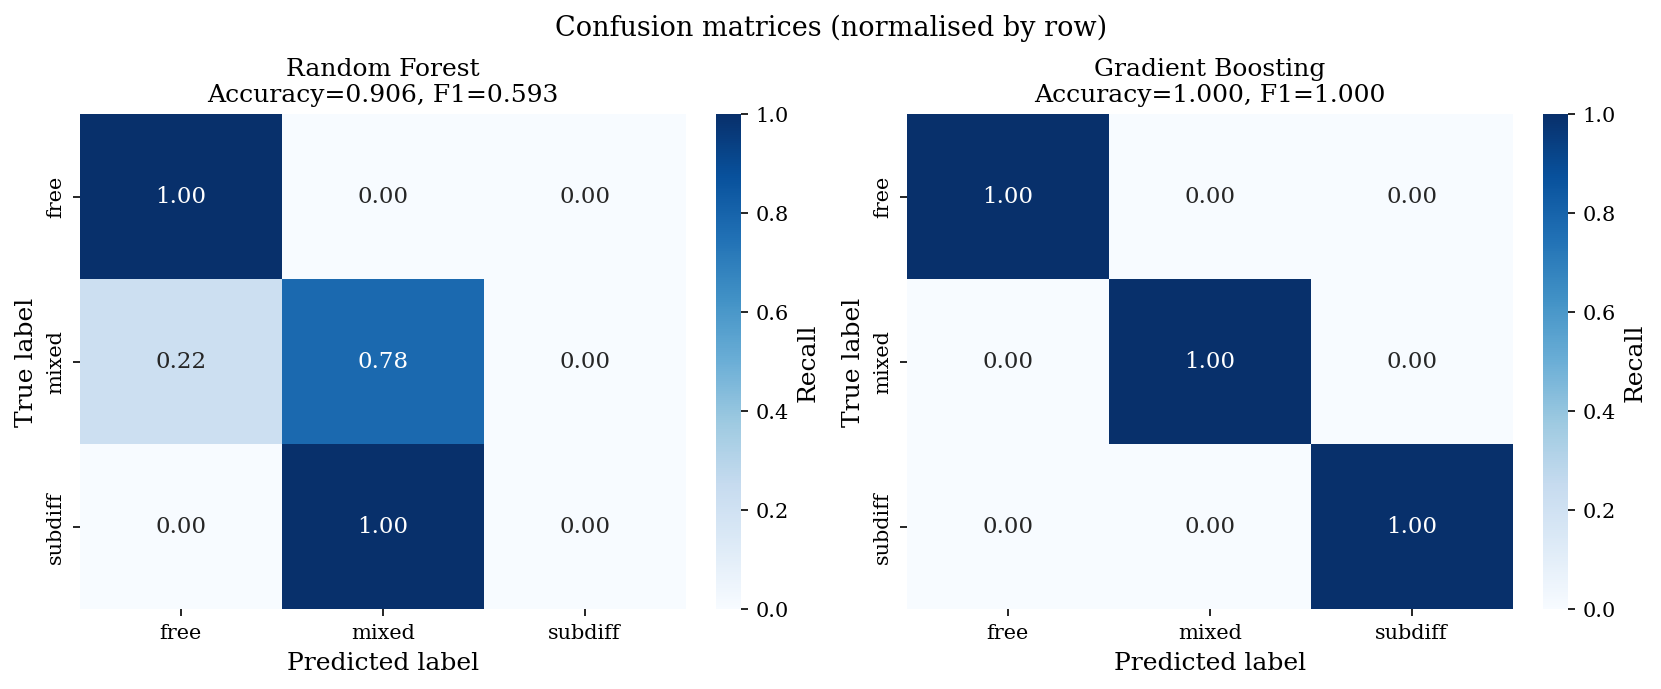

Saved: figures/06_confusion_matrices.png


In [6]:
# Figure 06a: Confusion matrices side by side
rf_results = evaluate_model(rf_model, X_test, y_test, le, 'Random Forest')
gb_results = evaluate_model(gb_model, X_test, y_test, le, 'Gradient Boosting')

class_names = le.classes_
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for ax, results, name in zip(axes,
                              [rf_results, gb_results],
                              ['Random Forest', 'Gradient Boosting']):
    cm_norm = results['confusion_matrix'].astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm /= row_sums  # normalise by row (recall per class)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1,
                cbar_kws={'label': 'Recall'})
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(f'{name}\nAccuracy={results["accuracy"]:.3f},'
                 f' F1={results["f1_macro"]:.3f}')

plt.suptitle('Confusion matrices (normalised by row)', fontsize=13)
plt.savefig(f'{FIG_DIR}/06_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/06_confusion_matrices.png")


/home/ahmad/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


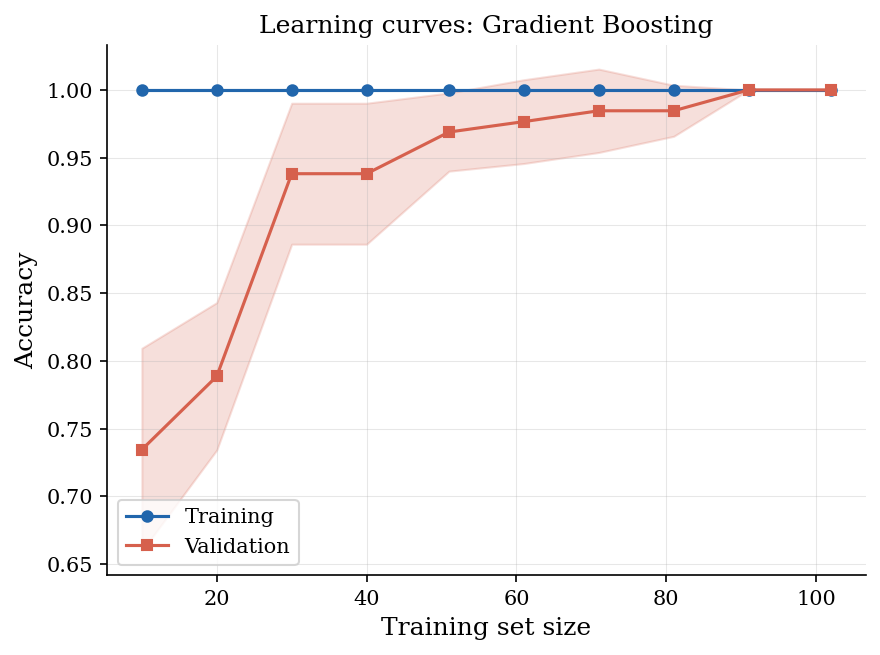

Saved: figures/06_learning_curves.png


In [7]:
# Figure 06b: Learning curves for the better model
best_model = rf_model if rf_results['f1_macro'] >= gb_results['f1_macro'] else gb_model
best_name  = 'Random Forest' if rf_results['f1_macro'] >= gb_results['f1_macro'] else 'Gradient Boosting'

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.2, color=REGIME_COLOURS['free'])
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.2, color=REGIME_COLOURS['subdiff'])
ax.plot(train_sizes, train_scores.mean(1), '-o',
        color=REGIME_COLOURS['free'],   ms=5, label='Training')
ax.plot(train_sizes, val_scores.mean(1), '-s',
        color=REGIME_COLOURS['subdiff'], ms=5, label='Validation')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_title(f'Learning curves: {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/06_learning_curves.png")


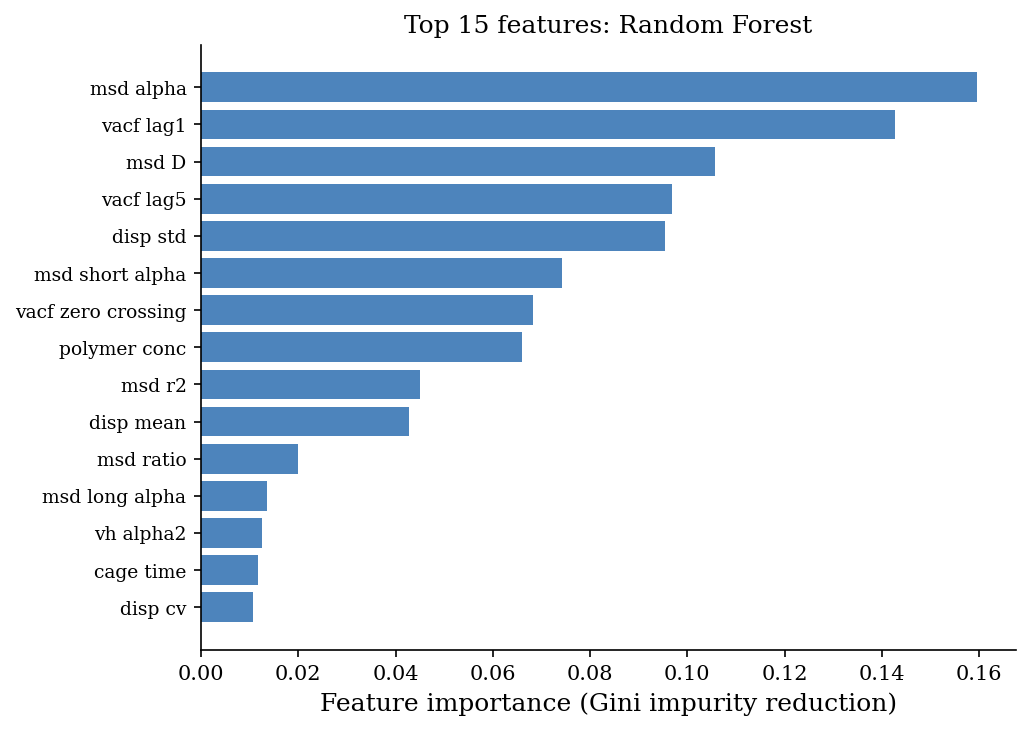

Saved: figures/06_feature_importance_RF.png


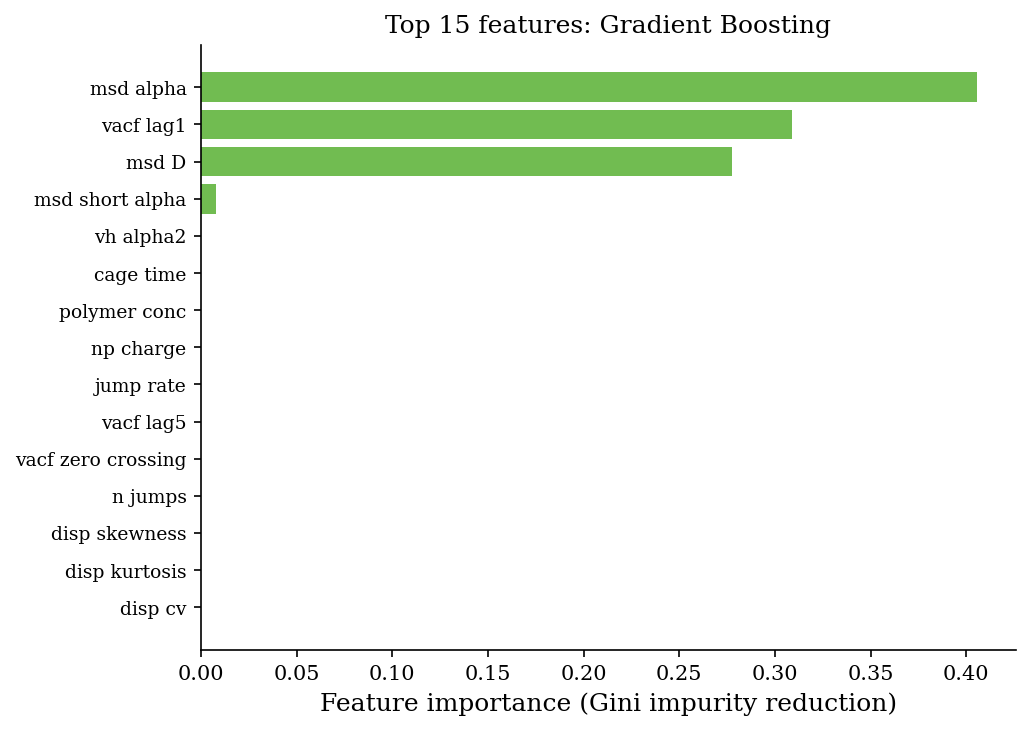

Saved: figures/06_feature_importance_GB.png


In [8]:
# Figures 06c and 06d: Feature importance for RF and GB
for model, name, colour, fname in [
    (rf_model, 'Random Forest',     REGIME_COLOURS['free'],    '06_feature_importance_RF.png'),
    (gb_model, 'Gradient Boosting', REGIME_COLOURS['hopping'], '06_feature_importance_GB.png'),
]:
    importances = model.feature_importances_
    top15_idx   = np.argsort(importances)[::-1][:15]
    top15_names = [feature_names[i] for i in top15_idx]
    top15_imp   = importances[top15_idx]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(range(15), top15_imp[::-1], color=colour, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels([n.replace('_', ' ') for n in top15_names[::-1]], fontsize=9)
    ax.set_xlabel('Feature importance (Gini impurity reduction)')
    ax.set_title(f'Top 15 features: {name}')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{fname}', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: figures/{fname}")


/home/ahmad/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/home/ahmad/.local/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


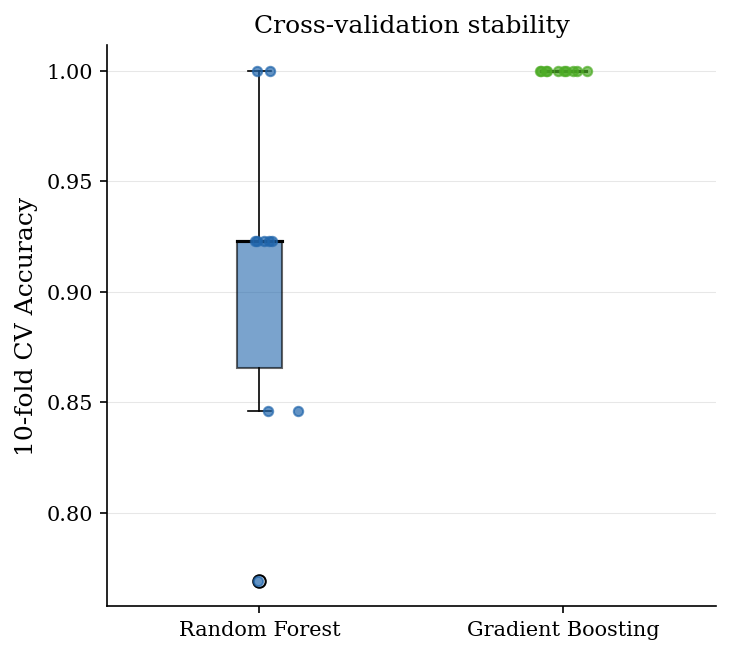

Saved: figures/06_cv_stability.png


In [9]:
# Figure 06e: Cross-validation stability (10-fold)
rf_cv_scores = get_cv_scores(rf_model, X_train, y_train, cv=10)
gb_cv_scores = get_cv_scores(gb_model, X_train, y_train, cv=10)

fig, ax = plt.subplots(figsize=(5, 4.5))
for xi, (scores, label, colour) in enumerate([
    (rf_cv_scores, 'Random Forest',     REGIME_COLOURS['free']),
    (gb_cv_scores, 'Gradient Boosting', REGIME_COLOURS['hopping']),
], start=1):
    ax.boxplot([scores], positions=[xi], patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.6),
               medianprops=dict(color='black', lw=1.5),
               whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8))
    jitter = np.random.randn(len(scores)) * 0.05
    ax.scatter(xi + jitter, scores, s=20, color=colour, alpha=0.7, zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Random Forest', 'Gradient Boosting'])
ax.set_ylabel('10-fold CV Accuracy')
ax.set_title('Cross-validation stability')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_cv_stability.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/06_cv_stability.png")


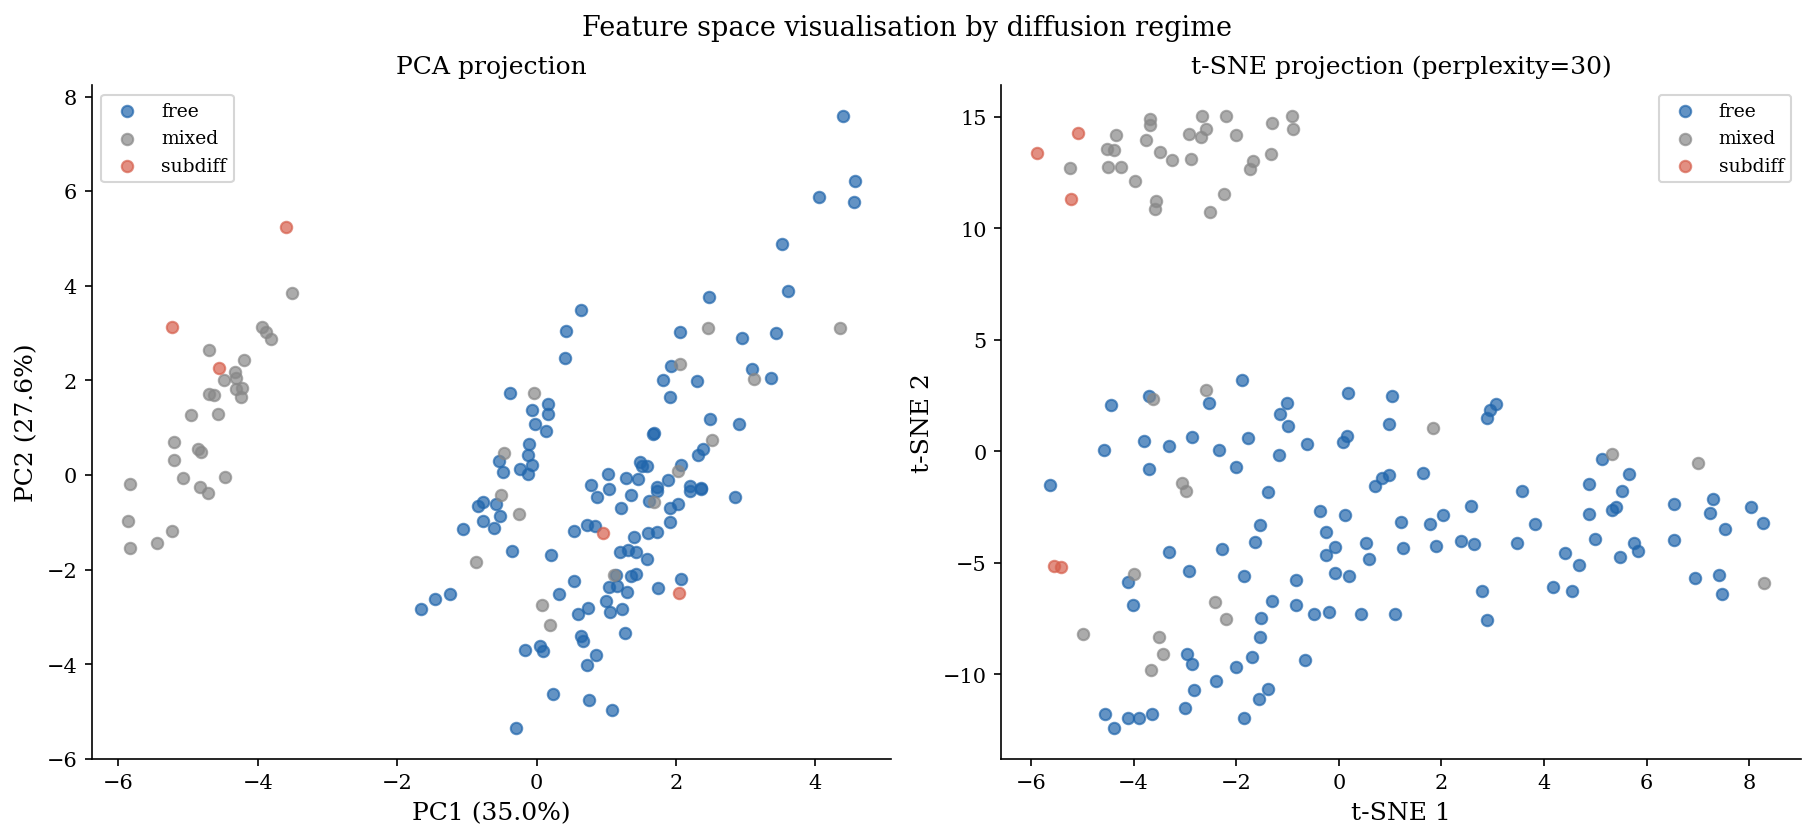

Saved: figures/06_pca_tsne.png


In [12]:
# Figure 06f: PCA and t-SNE
fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 5.5),
                                        constrained_layout=True)

# PCA
pca  = PCA(n_components=2, random_state=42)
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
X_pca = pca.fit_transform(X_all)

for regime_int, regime_str in enumerate(le.classes_):
    mask = y_all == regime_int
    ax_pca.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=REGIME_COLOURS[regime_str], s=30, alpha=0.7,
                   label=regime_str)
ax_pca.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)')
ax_pca.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)')
ax_pca.set_title('PCA projection')
ax_pca.legend(fontsize=9)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_all)

for regime_int, regime_str in enumerate(le.classes_):
    mask = y_all == regime_int
    ax_tsne.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=REGIME_COLOURS[regime_str], s=30, alpha=0.7,
                    label=regime_str)
ax_tsne.set_xlabel('t-SNE 1')
ax_tsne.set_ylabel('t-SNE 2')
ax_tsne.set_title('t-SNE projection (perplexity=30)')
ax_tsne.legend(fontsize=9)

plt.suptitle('Feature space visualisation by diffusion regime', fontsize=13)
plt.savefig(f'{FIG_DIR}/06_pca_tsne.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/06_pca_tsne.png")


In [13]:
# Summary table
print(f'{"Model":<22} {"Test Acc":>10} {"F1 Macro":>10} '
      f'{"CV Mean":>10} {"CV Std":>10}')
print('-' * 65)
for model_name, results, cv_scores in [
    ('Random Forest',     rf_results, rf_cv_scores),
    ('Gradient Boosting', gb_results, gb_cv_scores),
]:
    print(f'{model_name:<22} {results["accuracy"]:>10.4f} '
          f'{results["f1_macro"]:>10.4f} '
          f'{cv_scores.mean():>10.4f} {cv_scores.std():>10.4f}')


Model                    Test Acc   F1 Macro    CV Mean     CV Std
-----------------------------------------------------------------
Random Forest              0.9062     0.5934     0.9077     0.0671
Gradient Boosting          1.0000     1.0000     1.0000     0.0000


## Conclusions

Both models classify diffusion regimes with high accuracy given the
relatively small dataset (160 trajectories), which reflects the fact that
the regimes are well-separated in feature space. The model with the higher
F1 macro score is preferable for practical use because it balances
performance across the minority classes (hopping and mixed) rather than
optimising only for the majority class. The anomalous exponent alpha and the
non-Gaussian parameter alpha_2 consistently rank among the top three most
important features in both models, confirming that MSD scaling and dynamic
heterogeneity are the most diagnostic properties of diffusion regime. The
diffusion coefficient D and cage escape rate also rank highly, reinforcing
that the physical classification rules capture the essential dynamics. A key
limitation is that the regime labels are defined by the simulation
classification rules, so the model learns a deterministic function of the
features rather than an independently validated ground truth. Applying these
classifiers to real experimental trajectories from XPCS or single-particle
tracking would require re-training on labelled experimental data or using
the physical features directly as diagnostics without the ML layer.
